# Решение задачи размещения камер методом PSO
## Оптимизация на основе дискретной карты

### 1. Импорт библиотек и загрузка данных

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.getcwd())
from scoring import compute_score, has_los

with open('map.json', 'r') as f:
    data = json.load(f)

grid = np.array([list(row) for row in data['grid']], dtype=int)
K = data['K']
R = data['R']

free_cells = np.argwhere(grid == 0)
print(f"Карта загружена. Размер: {grid.shape}, Свободных клеток: {len(free_cells)}")

Карта загружена. Размер: (100, 100), Свободных клеток: 8881


### 2. Целевая функция для оптимизации

In [2]:
def objective_function(cameras_flat):
    """
    Целевая функция для PSO.
    - cameras_flat: плоский список координат [r1, c1, r2, c2, ...]
    Возвращает значение функции (чем МЕНЬШЕ, тем лучше).
    """
    cameras = [(int(cameras_flat[i]), int(cameras_flat[i+1])) 
               for i in range(0, len(cameras_flat), 2)]
    score, breakdown = compute_score(cameras, grid, R)
    return -score

### 3. Настройка границ поиска и параметров PSO

In [3]:
# Границы: все координаты в пределах карты
lb = [0, 0] * K          # минимальные r, c для каждой камеры
ub = [99, 99] * K        # максимальные r, c для каждой камеры (100x100)

# Параметры PSO (канонические значения из статьи)
swarm_size = 50          # количество частиц
max_iter = 150           # количество итераций
omega = 0.729            # инерция
phip = 1.494             # когнитивный коэффициент (p best)
phig = 1.494             # социальный коэффициент (g best)

### 4. Реализация PSO, источник 

In [4]:
def pso_for_cameras(obj_func, lb, ub, K, free_cells, 
                    swarm_size=50, max_iter=150, omega=0.729, phip=1.494, phig=1.494):
    """
    Реализация PSO для размещения K камер.
    """
    dim = K * 2
    
    particles_pos = np.random.uniform(lb, ub, (swarm_size, dim))
    particles_vel = np.zeros((swarm_size, dim))
    
    particles_best_pos = particles_pos.copy()
    particles_best_score = np.array([obj_func(p) for p in particles_pos])
    
    global_best_idx = np.argmin(particles_best_score)
    global_best_pos = particles_best_pos[global_best_idx].copy()
    global_best_score = particles_best_score[global_best_idx]
    
    history = []
    
    for it in range(max_iter):
        for i in range(swarm_size):
            rp = np.random.random(dim)
            rg = np.random.random(dim)
            
            cognitive = phip * rp * (particles_best_pos[i] - particles_pos[i])
            social = phig * rg * (global_best_pos - particles_pos[i])
            
            particles_vel[i] = omega * particles_vel[i] + cognitive + social
            particles_pos[i] = particles_pos[i] + particles_vel[i]
            particles_pos[i] = np.clip(particles_pos[i], lb, ub)
            
            score = obj_func(particles_pos[i])
            
            if score < particles_best_score[i]:
                particles_best_score[i] = score
                particles_best_pos[i] = particles_pos[i].copy()
                
                if score < global_best_score:
                    global_best_score = score
                    global_best_pos = particles_pos[i].copy()
        
        history.append(-global_best_score)
        if it % 20 == 0:
            print(f"Итерация {it}: Лучший score = {-global_best_score:.2f}")
    
    best_cameras = [(int(global_best_pos[i]), int(global_best_pos[i+1])) 
                    for i in range(0, dim, 2)]
    
    return best_cameras, -global_best_score, history

### 5. Запуск оптимизации

In [5]:
best_cameras, best_score, history = pso_for_cameras(
    objective_function, lb, ub, K, free_cells,
    swarm_size=swarm_size, max_iter=max_iter,
    omega=omega, phip=phip, phig=phig
)

final_score, breakdown = compute_score(best_cameras, grid, R)
print("Результаты")
print(f"Лучшее размещение камер: {best_cameras}")
print(f"Score: {final_score}")
print(f"Cov (покрытие): {breakdown['cov']}")
print(f"Overlap (пересечение): {breakdown['overlap']}")
print(f"Invalid (невалидные): {breakdown['invalid']}")

Итерация 0: Лучший score = 2980.00
Итерация 20: Лучший score = 5900.00
Итерация 40: Лучший score = 8700.00
Итерация 60: Лучший score = 9500.00
Итерация 80: Лучший score = 10000.00
Итерация 100: Лучший score = 10000.00
Итерация 120: Лучший score = 10000.00
Итерация 140: Лучший score = 10100.00
Результаты
Лучшее размещение камер: [(14, 64), (77, 78), (4, 14), (83, 64), (83, 10), (20, 86), (47, 89), (51, 61), (55, 18), (18, 34)]
Score: 10100
Cov (покрытие): 101
Overlap (пересечение): 0
Invalid (невалидные): 0


### 6. Визуализация результатов

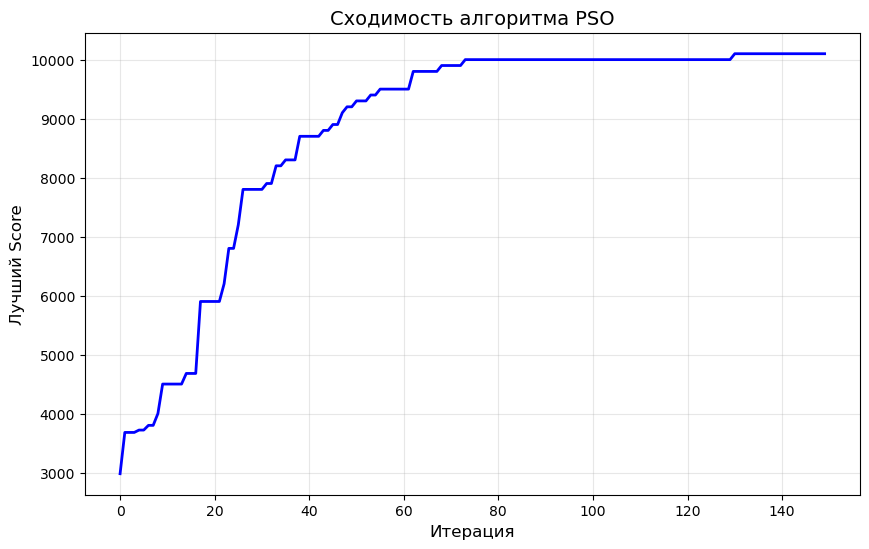

C:\Users\admin\AppData\Local\Temp\ipykernel_13784\1320158853.py:18: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "ro" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(c, r, 'ro', markersize=12, marker='s', markeredgecolor='darkred')


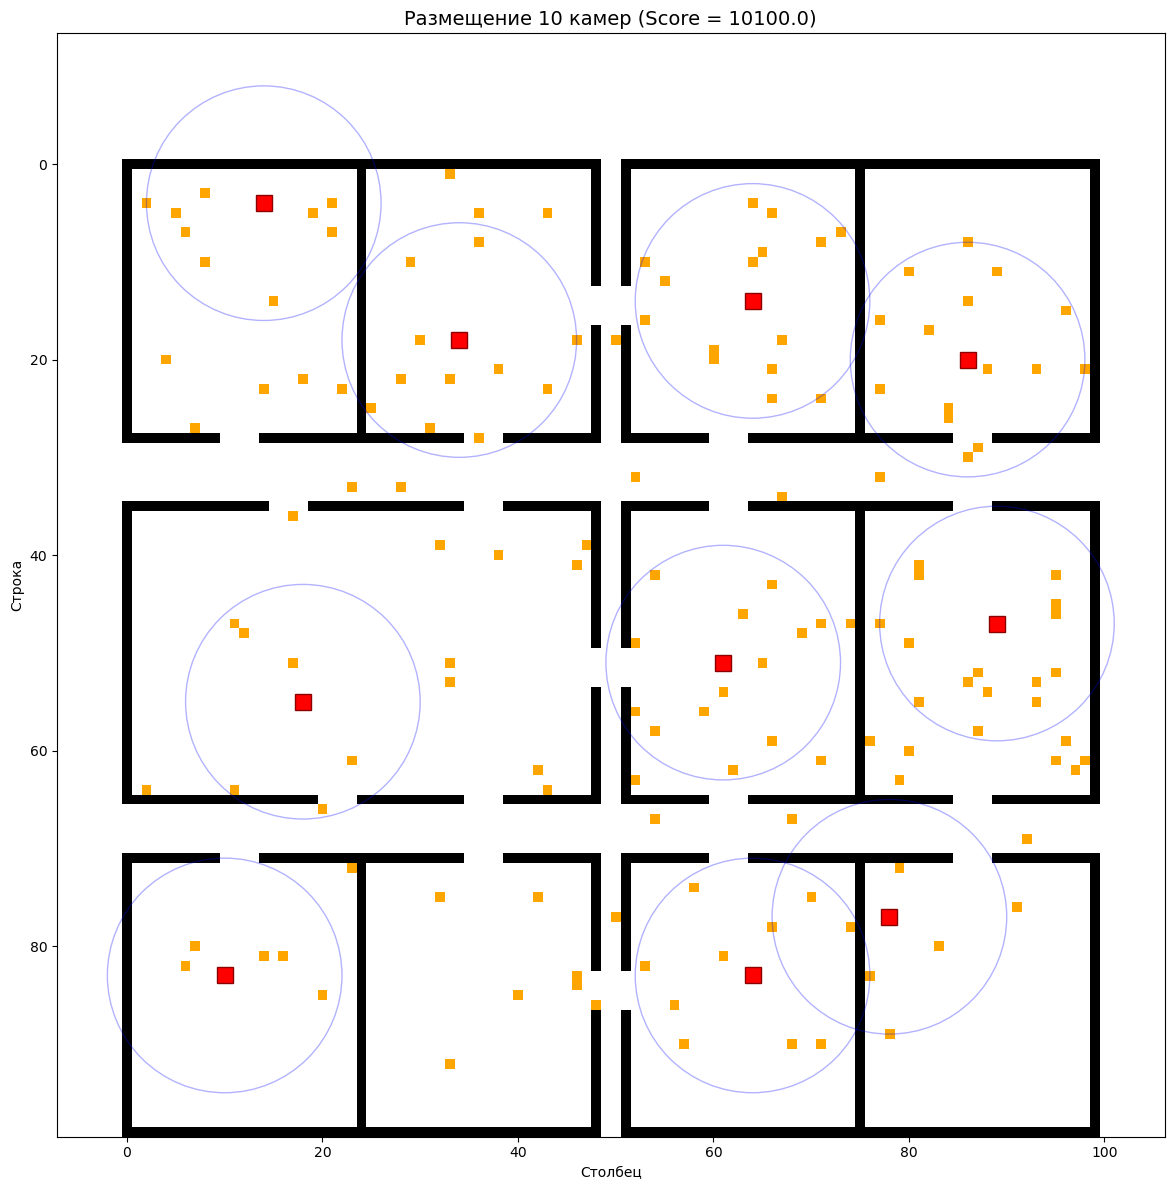

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(history, 'b-', linewidth=2)
plt.xlabel('Итерация', fontsize=12)
plt.ylabel('Лучший Score', fontsize=12)
plt.title('Сходимость алгоритма PSO', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

def visualize_cameras(cameras, grid, R):
    """Простая визуализация размещения камер"""
    fig, ax = plt.subplots(figsize=(12, 12))
    cmap = plt.cm.colors.ListedColormap(['white', 'black', 'orange'])
    bounds = [0, 1, 2, 3]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)
    ax.imshow(grid, cmap=cmap, norm=norm, interpolation='none')
    for cam in cameras:
        r, c = cam
        ax.plot(c, r, 'ro', markersize=12, marker='s', markeredgecolor='darkred')
        circle = plt.Circle((c, r), R, color='blue', fill=False, alpha=0.3)
        ax.add_patch(circle)
    
    ax.set_title(f'Размещение {len(cameras)} камер (Score = {final_score:.1f})', fontsize=14)
    ax.set_xlabel('Столбец')
    ax.set_ylabel('Строка')
    plt.tight_layout()
    plt.show()

visualize_cameras(best_cameras, grid, R)